# Ex.1 Camera calibration

This notebook performs intrinsic calibration from a set of images of a checkerboard displayed on a screen.
The checkerboard has 15x15 squares -> 14x14 inner corners, so set `CHECKERBOARD = (14, 14)`.

In [1]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# IMPORTANT: Set this to the number of INNER corners of your 
# checkerboard (columns, rows).
# ---------------------------------------------------------
CHECKERBOARD = (9, 9) 

# Termination criteria for refining the corner coordinates
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points: (0,0,0), (1,0,0), (2,0,0) ...., (8,5,0)

In [2]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# Number of INNER corners per a chessboard row and column
# For a 15x15 squares board, inner corners = 14x14
CHECKERBOARD = (9, 9)

# physical size of one square on the checkerboard (any consistent units).
# if you don't know it just leave it at 1.0; focal length in the
# resulting camera matrix will then be expressed in "square units".
SQUARE_SIZE = 0.010 # e.g. 0.024 for 24 mm squares

# Termination criteria for corner refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points in real world coordinates: (0,0,0), (1,0,0), ...
# multiply by SQUARE_SIZE so units match the physical board.
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = (np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) *
                SQUARE_SIZE)

# Storage for points from all images
objpoints = []
imgpoints = []

# Collect image files from the "fotogreg" subdirectory only
images = sorted(glob.glob('fotogreg/*.jpeg') + glob.glob('fotogreg/*.jpg') + glob.glob('fotogreg/*.png') + glob.glob('fotogreg/*.JPG'))
print(f'Found {len(images)} images in fotogreg/')

Found 7 images in fotogreg/


In [3]:
# Detect corners in each image (robust but concise pipeline)
img_shape = None
img_with_corners = None
found = 0

flags = cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_NORMALIZE_IMAGE

for fname in images:
    img = cv2.imread(fname)
    if img is None:
        print(f'Could not read {fname}')
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img_shape is None:
        img_shape = gray.shape[::-1]

    # Apply CLAHE to improve contrast (useful on displays)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_enh = clahe.apply(gray)

    # Try standard detector with flags
    ret, corners = cv2.findChessboardCorners(gray_enh, CHECKERBOARD, flags)

    # If not found, try the original gray image (sometimes better)
    if not ret:
        ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, flags)

    # As a fallback try the newer SB detector if available
    if not ret:
        try:
            ret, corners = cv2.findChessboardCornersSB(gray_enh, CHECKERBOARD, None)
        except Exception:
            ret = False

    if ret:
        # Refine and store
        corners_refined = cv2.cornerSubPix(gray_enh, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp.copy())
        imgpoints.append(corners_refined)
        img_with_corners = cv2.drawChessboardCorners(img.copy(), CHECKERBOARD, corners_refined, True)
        found += 1
        print(f'Found corners in {fname} (total {found})')
    else:
        print(f'No corners in {fname}')

print(f'\nDetection finished: {found}/{len(images)} images with corners')

Found corners in fotogreg/IMG_6971.jpg (total 1)
Found corners in fotogreg/IMG_6972.jpg (total 2)
Found corners in fotogreg/IMG_6973.jpg (total 3)
Found corners in fotogreg/IMG_6974.jpg (total 4)
Found corners in fotogreg/IMG_6975.jpg (total 5)
Found corners in fotogreg/IMG_6976.jpg (total 6)
Found corners in fotogreg/IMG_6977.jpg (total 7)

Detection finished: 7/7 images with corners


In [4]:
# Calibrate if enough views were found and save results
# This section follows ViSP recommendation: use 5–15 good, oblique views
# that fill the frame; avoid images where the board is parallel to the image
# plane.  If some pictures are blurry or corners mis‑detected, they will
# produce high reprojection error and we can drop them later.
if len(objpoints) >= 3:
    # Build an initial intrinsic guess from the image size (helps solver)
    # and use rational model plus use-intrinsic-guess flag for stability.
    calib_flags = cv2.CALIB_RATIONAL_MODEL | cv2.CALIB_USE_INTRINSIC_GUESS

    camera_init = None
    if img_shape is not None:
        w, h = img_shape
        # reasonable initial focal length estimate (in pixels)
        est_f = max(w, h) * 1.2
        camera_init = np.array([[est_f, 0.0, w/2.0],
                                [0.0, est_f, h/2.0],
                                [0.0, 0.0, 1.0]], dtype=np.float64)

    # first calibration pass
    retval, mtx, dist, rvecs, tvecs, stdIntr, stdExtr, perViewErr = \
        cv2.calibrateCameraExtended(objpoints, imgpoints, img_shape,
                                     camera_init, None, flags=calib_flags)

    print('=== Calibration Successful (initial pass) ===')
    print('\n1. Camera Matrix (intrinsics):')
    print(mtx)
    # check principal point versus image center
    if img_shape is not None:
        w, h = img_shape
        print(f'   expected center ≈ ({w/2:.1f}, {h/2:.1f}), got ' \
              f'({mtx[0,2]:.1f}, {mtx[1,2]:.1f})')
    # aspect ratio fx/fy should be close to 1
    print(f'   fx/fy = {mtx[0,0]/mtx[1,1]:.3f}')
    print('\n2. Distortion Coefficients:')
    print(dist.ravel())

    # report per-view reprojection errors and drop big outliers
    print('\nPer-view reprojection errors:')
    for fname, err in zip(images, perViewErr):
        print(f'  {fname}: {err}')
    # remove any image with error > 10 pixel (adjust threshold as needed)
    threshold = 10.0
    bad_idx = [i for i, e in enumerate(perViewErr) if e > threshold]
    if bad_idx:
        print(f'\nRemoving {len(bad_idx)} high-error images and recalibrating...')
        # filter lists
        objpoints = [o for i, o in enumerate(objpoints) if i not in bad_idx]
        imgpoints = [p for i, p in enumerate(imgpoints) if i not in bad_idx]
        images = [f for i, f in enumerate(images) if i not in bad_idx]
        # second calibration
        retval, mtx, dist, rvecs, tvecs, stdIntr, stdExtr, perViewErr = \
            cv2.calibrateCameraExtended(objpoints, imgpoints, img_shape,
                                         camera_init, None, flags=calib_flags)
        print('=== Calibration Successful (after outlier removal) ===')
        print('Recomputed camera matrix and distortion coefficients below:')
        print(mtx)
        print(dist.ravel())

    # Reprojection error (fallback computation)
    mean_error = 0
    for i in range(len(objpoints)):
        imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
        mean_error += error
    mean_error /= len(objpoints)
    print(f'\nTotal re-projection error: {mean_error:.4f} pixels')

    # Save calibration (include flags used for reproducibility)
    np.savez('calibration.npz', camera_matrix=mtx, dist_coeffs=dist,
             reprojection_error=mean_error, flags=int(calib_flags))
    print('\nSaved calibration to calibration.npz')

else:
    print('Not enough valid images for calibration. Need at least 3 with detected corners.')

=== Calibration Successful (initial pass) ===

1. Camera Matrix (intrinsics):
[[4.54625102e+03 0.00000000e+00 2.86475186e+03]
 [0.00000000e+00 4.54503916e+03 2.25192679e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
   expected center ≈ (2856.0, 2142.0), got (2864.8, 2251.9)
   fx/fy = 1.000

2. Distortion Coefficients:
[ 1.63845672e+02  7.26699727e+01  5.64917182e-04  3.94718881e-04
 -3.18115365e+01  1.52780139e+02  7.91339674e+01  1.29368280e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]

Per-view reprojection errors:
  fotogreg/IMG_6971.jpg: [7.3118247]
  fotogreg/IMG_6972.jpg: [7.59362211]
  fotogreg/IMG_6973.jpg: [9.31011226]
  fotogreg/IMG_6974.jpg: [7.04168803]
  fotogreg/IMG_6975.jpg: [7.01207865]
  fotogreg/IMG_6976.jpg: [6.88534568]
  fotogreg/IMG_6977.jpg: [6.90305928]

Total re-projection error: 0.8263 pixels

Saved calibration to calibration.npz


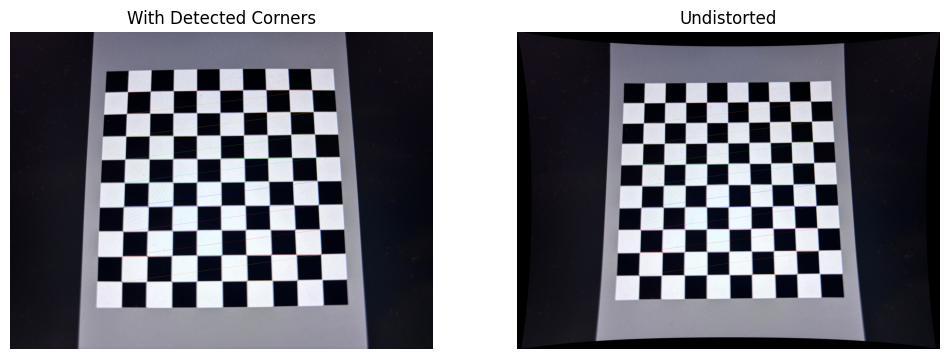

In [5]:
# Show example undistortion on the last image with detected corners
if img_with_corners is not None and 'mtx' in globals():
    img = img_with_corners
    h, w = img.shape[:2]
    # distortion coefficients from calibration; flip sign manually below if
    # the correction appears reversed
    dist_used = dist
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist_used, (w, h), 1, (w, h))
    undist = cv2.undistort(img, mtx, dist_used, None, newcameramtx)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('With Detected Corners')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Undistorted')
    plt.imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print('No example image to show undistortion.')

In [6]:
# Export calibration to JSON and YAML (OpenCV FileStorage)
import numpy as np
import json
import cv2
from pathlib import Path

data_path = Path('calibration.npz')
if not data_path.exists():
    print('calibration.npz not found. Run calibration first.')
else:
    data = np.load(str(data_path))
    mtx = data['camera_matrix']
    dist = data['dist_coeffs']
    reproj = float(data['reprojection_error']) if 'reprojection_error' in data else None

    # Write JSON
    out_json = {
        'camera_matrix': mtx.tolist(),
        'dist_coeffs': dist.ravel().tolist(),
        'reprojection_error': reproj
    }
    with open('calibration.json', 'w') as f:
        json.dump(out_json, f, indent=2)

    # Write YAML using OpenCV FileStorage
    fs = cv2.FileStorage('calibration.yml', cv2.FILE_STORAGE_WRITE)
    fs.write('camera_matrix', mtx)
    fs.write('dist_coeffs', dist)
    if reproj is not None:
        fs.write('reprojection_error', reproj)
    fs.release()

    print('Wrote calibration.json and calibration.yml')

Wrote calibration.json and calibration.yml


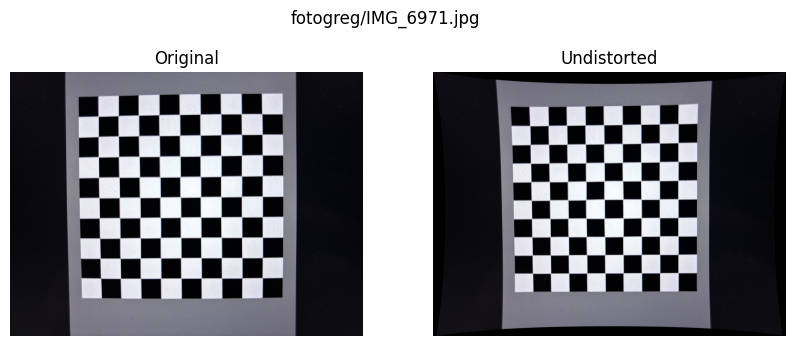

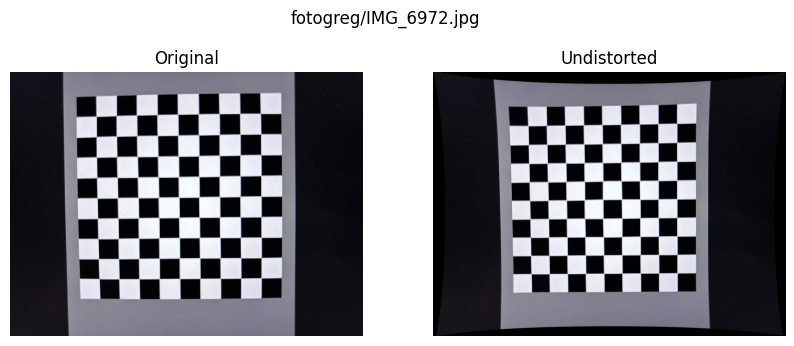

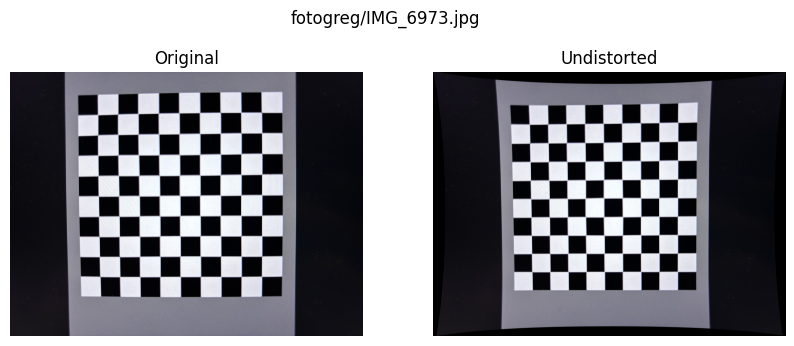

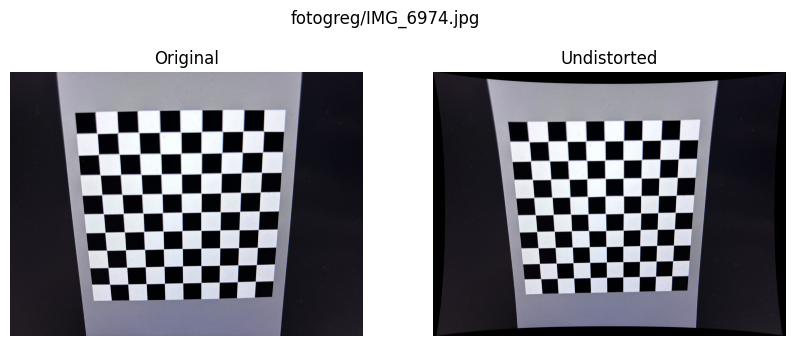

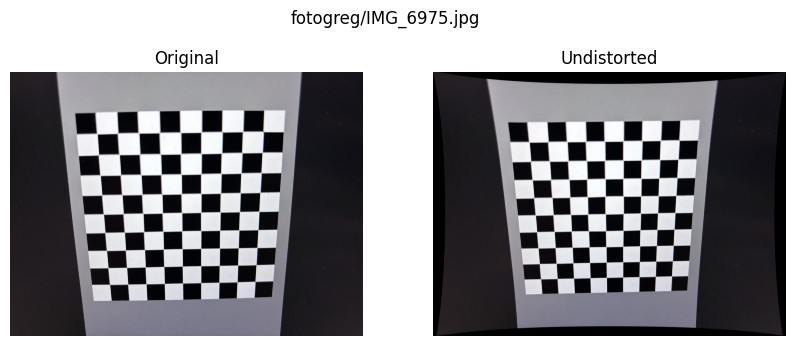

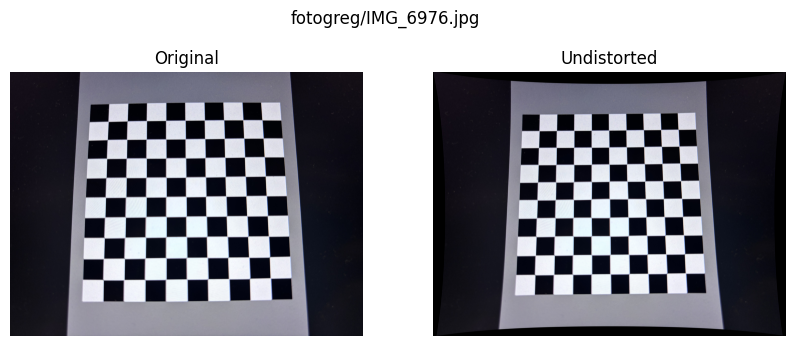

In [7]:
# Additional examples: undistort several images using the saved calibration
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# load previously saved calibration parameters
calib = np.load('calibration.npz')
mtx = calib['camera_matrix']
dist = calib['dist_coeffs']

# collect all image files again
images = sorted(glob.glob('fotogreg/*.jpeg') + glob.glob('fotogreg/*.jpg') + glob.glob('fotogreg/*.png')+ glob.glob('fotogreg/*.JPG'))

if not images:
    print('No images found in working directory to undistort.')
else:
    # display a few examples side by side
    # if the undistorted pictures look worse, try flipping the sign of dist
    for fname in images[:6]:  # change number as needed
        img = cv2.imread(fname)
        h, w = img.shape[:2]
        dist_used = dist
        newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist_used, (w, h), 1, (w, h))
        undist = cv2.undistort(img, mtx, dist_used, None, newcameramtx)

        plt.figure(figsize=(10, 4))
        plt.suptitle(fname)
        plt.subplot(1, 2, 1)
        plt.title('Original')
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Undistorted')
        plt.imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.show()

Undistorted images saved to /Users/tommasoaiello/Desktop/Magistrale/Secondo Semestre/Computer Vision/HomeWork/undistorted


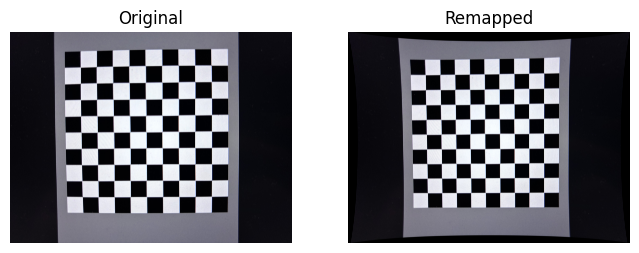

In [8]:
# save undistorted outputs for all images to an "undistorted" folder
import os
os.makedirs('undistorted', exist_ok=True)

for fname in images:
    img = cv2.imread(fname)
    h, w = img.shape[:2]
    dist_used = dist
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist_used, (w, h), 1, (w, h))
    undist = cv2.undistort(img, mtx, dist_used, None, newcameramtx)

    # ORIGINAL (commented): crop to ROI if desired
    # x, y, w2, h2 = roi
    # if w2 > 0 and h2 > 0:
    #     undist = undist[y:y+h2, x:x+w2]

    # keep full-size undistorted image by default
    outname = os.path.join('undistorted', os.path.basename(fname))
    cv2.imwrite(outname, undist)

print(f'Undistorted images saved to {os.path.abspath("undistorted")}')

# also demonstrate remapping approach (useful for video)
# using the same new camera matrix and dist_used as above
mapx, mapy = cv2.initUndistortRectifyMap(mtx, dist_used, None, newcameramtx, (w, h), cv2.CV_32FC1)
example = cv2.imread(images[0])
remapped = cv2.remap(example, mapx, mapy, cv2.INTER_LINEAR)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.title('Original'); plt.imshow(cv2.cvtColor(example, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,2,2); plt.title('Remapped'); plt.imshow(cv2.cvtColor(remapped, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()